In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import jit, prange
import os
import time

In [2]:
@jit(nopython=True, fastmath=True)
def kolchinsky_bounds_float32(T, Y, sigma2):
    """Implementazione VELOCE float32"""
    # Converti input a float32
    T = T.astype(np.float32)
    sigma2 = np.float32(sigma2)
    
    n_samples, n_features = T.shape
    c_up, c_low = np.float32(1.0), np.float32(4.0)
    
    # 1. PRE-CALCOLO NORME in float32
    norms = np.zeros(n_samples, dtype=np.float32)
    for i in range(n_samples):
        norm = np.float32(0.0)
        Ti = T[i]
        for k in range(n_features):
            val = Ti[k]
            norm += val * val
        norms[i] = norm
    
    # 2. PRE-CALCOLO INDICI CLASSI
    unique_y = np.unique(Y)
    class_indices = []
    for cls in unique_y:
        indices = np.where(Y == cls)[0]
        class_indices.append(indices)
    
    # 3. CALCOLO H_X (float32 ottimizzato)
    def compute_H(sigma2, c):
        denom = np.float32(2.0) * c * sigma2
        log_sum = np.float32(0.0)
        
        for i in range(n_samples):
            row_sum = np.float32(0.0)
            norm_i = norms[i]
            Ti = T[i]
            
            for j in range(n_samples):
                if i == j:
                    row_sum += np.float32(1.0)
                else:
                    # Prodotto scalare
                    dot = np.float32(0.0)
                    Tj = T[j]
                    for k in range(n_features):
                        dot += Ti[k] * Tj[k]
                    
                    distance = norm_i + norms[j] - np.float32(2.0) * dot
                    row_sum += np.exp(-distance / denom)
            
            log_sum += np.log(row_sum / n_samples + np.float32(1e-12))
        
        return -log_sum / n_samples
    
    # 4. CALCOLO H_X_givenY
    def compute_H_givenY(sigma2, c):
        denom = np.float32(2.0) * c * sigma2
        total = np.float32(0.0)
        
        for class_idx in class_indices:
            n_class = len(class_idx)
            if n_class > 0:
                class_sum = np.float32(0.0)
                
                for i_idx in range(n_class):
                    i = class_idx[i_idx]
                    row_sum = np.float32(0.0)
                    norm_i = norms[i]
                    Ti = T[i]
                    
                    for j_idx in range(n_class):
                        j = class_idx[j_idx]
                        if i == j:
                            row_sum += np.float32(1.0)
                        else:
                            dot = np.float32(0.0)
                            Tj = T[j]
                            for k in range(n_features):
                                dot += Ti[k] * Tj[k]
                            
                            distance = norm_i + norms[j] - np.float32(2.0) * dot
                            row_sum += np.exp(-distance / denom)
                    
                    class_sum += np.log(row_sum / n_class + np.float32(1e-12))
                
                total += -class_sum
        
        return total / n_samples
    
    # 5. CALCOLA TUTTO
    H_X_up = compute_H(sigma2, c_up)
    H_X_low = compute_H(sigma2, c_low)
    H_X_givenY_up = compute_H_givenY(sigma2, c_up)
    H_X_givenY_low = compute_H_givenY(sigma2, c_low)
    
    I_XY_up = H_X_up - H_X_givenY_up
    I_XY_low = H_X_low - H_X_givenY_low
    
    # Ritorna come float64 per consistenza
    return (float(H_X_up), float(I_XY_up), 
            float(H_X_low), float(I_XY_low))

In [3]:
class FastSaxeAnalyzer:
    def __init__(self, sigma2=0.1, sample_size=1000):
        self.sigma2 = sigma2
        self.sample_size = sample_size
        
    def compute_bounds(self, T, Y):
        """Calcola bounds VELOCEMENTE"""
        n_samples = T.shape[0]
        
        # Campiona se necessario (mantenendo distribuzione classi)
        if self.sample_size and n_samples > self.sample_size:
            unique_y = np.unique(Y)
            samples_per_class = self.sample_size // len(unique_y)
            
            indices = []
            for cls in unique_y:
                cls_idx = np.where(Y == cls)[0]
                n_take = min(len(cls_idx), samples_per_class)
                chosen = np.random.choice(cls_idx, n_take, replace=False)
                indices.extend(chosen)
            
            # Assicurati di avere esattamente sample_size
            if len(indices) > self.sample_size:
                indices = indices[:self.sample_size]
            elif len(indices) < self.sample_size:
                # Aggiungi random se necessario
                extra = np.random.choice(n_samples, self.sample_size - len(indices), replace=False)
                indices.extend(extra)
            
            indices = np.array(indices)
            T = T[indices]
            Y = Y[indices]
            n_samples = len(indices)
        
        # Usa funzione float32 ottimizzata
        H_X_up, I_XY_up, H_X_low, I_XY_low = kolchinsky_bounds_float32(T, Y, self.sigma2)
        
        return {
            'H_X_up': max(0, H_X_up / np.log(2)),
            'I_XY_up': max(0, I_XY_up / np.log(2)),
            'H_X_low': max(0, H_X_low / np.log(2)),
            'I_XY_low': max(0, I_XY_low / np.log(2)),
            'n_samples': n_samples
        }

In [10]:
FOLDER_PATH = 'MNIST_CNN_conv_16-32_256-0_64-1_Tanh'

data = np.load(os.path.join(FOLDER_PATH, 'data.npz'))
Y_labels = data['true_labels']

# Carica attivazioni
layers = {}
layer_names = []

for file in sorted(os.listdir(FOLDER_PATH)):
    if file != 'data.npz':
        layer_name = file.removesuffix('.npz')
        layer_names.append(layer_name)
        layer_data = np.load(os.path.join(FOLDER_PATH, file))
        
        layer_activations = []
        n_epochs = len(layer_data.files)
        for i in range(n_epochs):
            layer_activations.append(layer_data[f'arr_{i}'])
        
        layers[layer_name] = layer_activations

In [25]:
sigma2 = 1
sample_size = 1500
n_epochs_total = len(layers[layer_names[0]])
n_epochs_to_analyze = 100  


print("\n" + "=" * 70)
print("CONFIGURAZIONE CALCOLO")
print("=" * 70)
print(f"σ² = {sigma2}")
print(f"Batch size per MI = {sample_size}")
print(f"H(X)_max teorico = log2({sample_size}) = {np.log2(sample_size):.2f} bits")

analyzer = FastSaxeAnalyzer(sigma2=sigma2, sample_size=sample_size)

# Inizializza risultati
results = {}
for layer_name in layer_names:
    results[layer_name] = {
        'I_XT_up': [], 'I_TY_up': [], 
        'I_XT_low': [], 'I_TY_low': [],
        'epochs': []
    }

print(f"\nCalcolo MI per {n_epochs_to_analyze} epoche...")
print("=" * 50)

start_time = time.time()

for epoch in range(n_epochs_to_analyze):
    epoch_start = time.time()
    
    for layer_idx, layer_name in enumerate(layer_names):
        T = layers[layer_name][epoch]
        Y = Y_labels[:T.shape[0]]
        
        bounds = analyzer.compute_bounds(T, Y)
        
        results[layer_name]['I_XT_up'].append(bounds['H_X_up'])
        results[layer_name]['I_TY_up'].append(bounds['I_XY_up'])
        results[layer_name]['I_XT_low'].append(bounds['H_X_low'])
        results[layer_name]['I_TY_low'].append(bounds['I_XY_low'])
        results[layer_name]['epochs'].append(epoch)
    
    epoch_time = time.time() - epoch_start
    total_time_so_far = time.time() - start_time
    avg_time_per_epoch = total_time_so_far / (epoch + 1)
    
    # Stampa per OGNI epoca con tempo cumulativo
    print(f"Epoca {epoch+1:3d}/{n_epochs_to_analyze}: "
          f"{epoch_time:6.2f}s (cum: {total_time_so_far:7.1f}s, "
          f"avg: {avg_time_per_epoch:5.2f}s/ep, "
          f"ETA: {avg_time_per_epoch * (n_epochs_to_analyze - epoch - 1) / 60:5.1f}m)")

total_time = time.time() - start_time
print(f"\n{'='*50}")
print(f"CALCOLO COMPLETATO!")
print(f"TEMPO TOTALE: {total_time:.1f} secondi ({total_time/60:.1f} minuti)")
print(f"Tempo medio per epoca: {total_time/n_epochs_to_analyze:.2f}s")
print(f"Epoche calcolate: {n_epochs_to_analyze}/{n_epochs_total}")


CONFIGURAZIONE CALCOLO
σ² = 1
Batch size per MI = 1500
H(X)_max teorico = log2(1500) = 10.55 bits

Calcolo MI per 100 epoche...
Epoca   1/100:   0.31s (cum:     0.3s, avg:  0.31s/ep, ETA:   0.5m)
Epoca   2/100:   0.31s (cum:     0.6s, avg:  0.31s/ep, ETA:   0.5m)
Epoca   3/100:   0.31s (cum:     0.9s, avg:  0.31s/ep, ETA:   0.5m)
Epoca   4/100:   0.31s (cum:     1.2s, avg:  0.31s/ep, ETA:   0.5m)
Epoca   5/100:   0.31s (cum:     1.6s, avg:  0.31s/ep, ETA:   0.5m)
Epoca   6/100:   0.31s (cum:     1.9s, avg:  0.31s/ep, ETA:   0.5m)
Epoca   7/100:   0.31s (cum:     2.2s, avg:  0.31s/ep, ETA:   0.5m)
Epoca   8/100:   0.32s (cum:     2.5s, avg:  0.31s/ep, ETA:   0.5m)
Epoca   9/100:   0.32s (cum:     2.8s, avg:  0.31s/ep, ETA:   0.5m)
Epoca  10/100:   0.32s (cum:     3.1s, avg:  0.31s/ep, ETA:   0.5m)
Epoca  11/100:   0.31s (cum:     3.4s, avg:  0.31s/ep, ETA:   0.5m)
Epoca  12/100:   0.32s (cum:     3.8s, avg:  0.31s/ep, ETA:   0.5m)
Epoca  13/100:   0.32s (cum:     4.1s, avg:  0.31s/ep, 

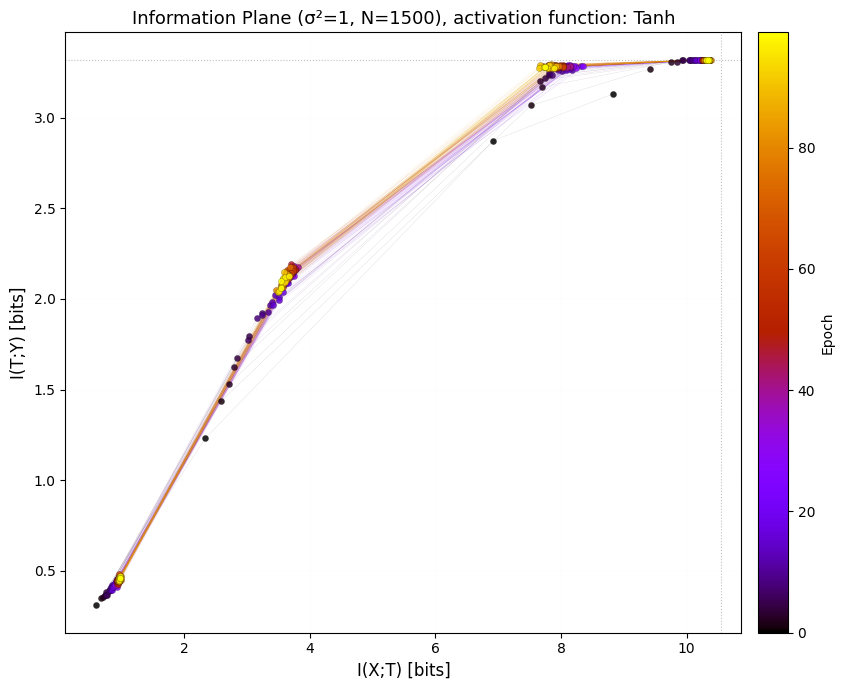

In [26]:
plt.figure(figsize=(9, 7))

colormap = plt.colormaps['gnuplot']
norm = plt.Normalize(0, n_epochs_to_analyze-1)

# 1. Plot dei PUNTI (upper bounds only)
for epoch in range(n_epochs_to_analyze):
    epoch_points_x = []
    epoch_points_y = []
    
    for layer_name in layer_names:
        epoch_points_x.append(results[layer_name]['I_XT_up'][epoch])
        epoch_points_y.append(results[layer_name]['I_TY_up'][epoch])
    
    plt.scatter(epoch_points_x, epoch_points_y,
               color=colormap(norm(epoch)),
               s=20, alpha=0.85, edgecolors='black',
               linewidth=0.15, marker='o',
               zorder=5)

# 2. Linee nere che collegano LAYERS a epoca fissata
for epoch in range(n_epochs_to_analyze):
    points = []
    for layer_name in layer_names:
        points.append((results[layer_name]['I_XT_up'][epoch],
                      results[layer_name]['I_TY_up'][epoch]))
    
    points.sort(key=lambda x: x[0])
    x_vals = [p[0] for p in points]
    y_vals = [p[1] for p in points]
    
    plt.plot(x_vals, y_vals, '-', color=colormap(norm(epoch)),
            alpha=0.4, linewidth=0.1, zorder=2)

# 3. Assi e labels
plt.xlabel('I(X;T) [bits]', fontsize=12)
plt.ylabel('I(T;Y) [bits]', fontsize=12)
plt.title(f'Information Plane (σ²={sigma2}, N={sample_size}), activation function: Tanh', fontsize=13)

# 4. Scale con MARGINI
H_X_max = np.log2(sample_size)
max_I_TY = np.log2(10)
x_margin_min = 6.86
y_margin_min = 2.88
x_margin_max = ((H_X_max-x_margin_min) * 1.02) + x_margin_min        #+2%
y_margin_max = ((max_I_TY-y_margin_min) * 1.02) + y_margin_min

#plt.xlim(x_margin_min, x_margin_max)  
#plt.ylim(y_margin_min, y_margin_max)  

# 5. Linee teoriche
plt.axhline(y=max_I_TY, color='gray', linestyle=':', 
           alpha=0.5, linewidth=0.8, zorder=0,
           label=f'Max I(T;Y)={max_I_TY:.2f}')

plt.axvline(x=H_X_max, color='gray', linestyle=':', 
           alpha=0.5, linewidth=0.8, zorder=0,
           label=f'H(X)_max={H_X_max:.2f}')

# 6. Colorbar
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
cbar.set_label('Epoch', fontsize=10)

plt.grid(True, alpha=0.05, linestyle='-', linewidth=0.3)

plt.tight_layout()
plt.show()

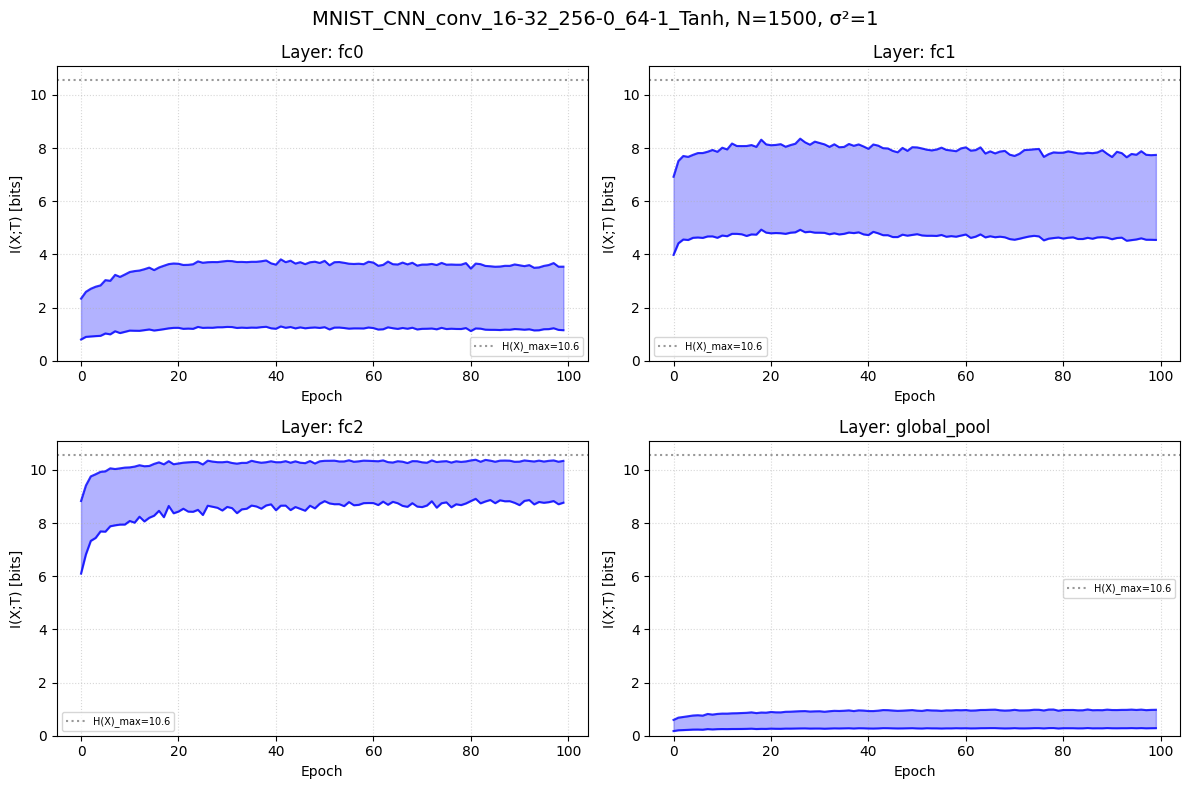

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (layer_name, ax) in enumerate(zip(layer_names, axes)):
    epochs = results[layer_name]['epochs']
    I_XT_up = results[layer_name]['I_XT_up']
    I_XT_low = results[layer_name]['I_XT_low']
    
    ax.fill_between(epochs, I_XT_low, I_XT_up, alpha=0.3, color='blue')
    
    ax.plot(epochs, I_XT_up, 'b-', linewidth=1.5, alpha=0.8)
    ax.plot(epochs, I_XT_low, 'b-', linewidth=1.5, alpha=0.8)
    
    ax.axhline(y=H_X_max, color='gray', linestyle=':',alpha=0.8, linewidth=1.5, label=f'H(X)_max={H_X_max:.1f}')
    
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('I(X;T) [bits]', fontsize=10)
    ax.set_title(f'Layer: {layer_name}', fontsize=12)
    ax.legend(loc='best', fontsize=7)
    ax.grid(True, alpha=0.5, linestyle=':')
    ax.set_ylim(0, H_X_max * 1.05)

fig.suptitle(f'{FOLDER_PATH}, N={sample_size}, σ²={sigma2}', fontsize=14)
plt.tight_layout()
plt.show()

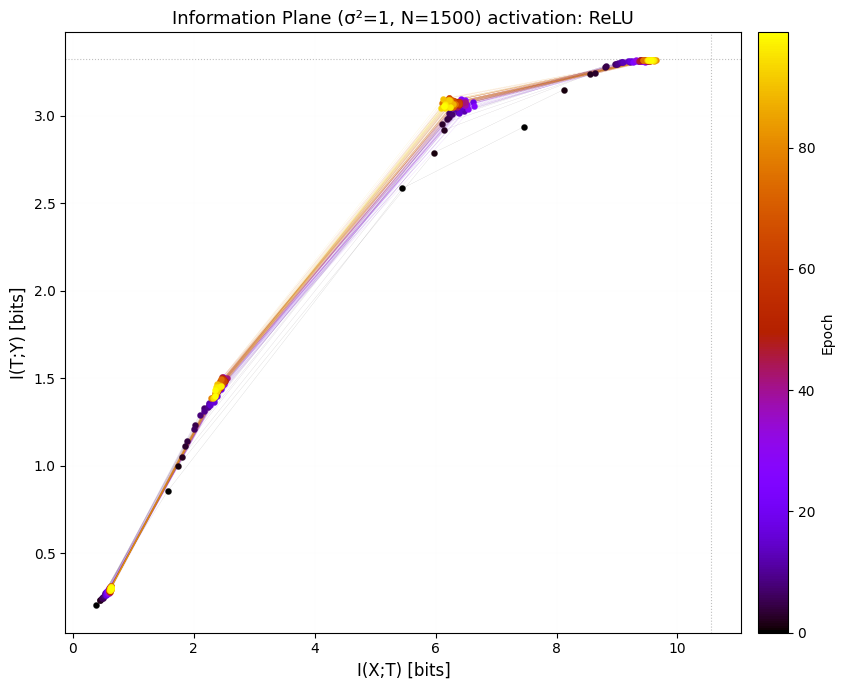

In [28]:
plt.figure(figsize=(9, 7))

# Colormap per epoche
colormap = plt.colormaps['gnuplot']
norm = plt.Normalize(0, n_epochs_to_analyze-1)

# 1. Plot dei PUNTI (media upper/lower)
for epoch in range(n_epochs_to_analyze):
    epoch_points_x = []
    epoch_points_y = []
    
    for layer_name in layer_names:
        I_XT_mean = 0.5 * (results[layer_name]['I_XT_up'][epoch] +
                           results[layer_name]['I_XT_low'][epoch])
        I_TY_mean = 0.5 * (results[layer_name]['I_TY_up'][epoch] +
                           results[layer_name]['I_TY_low'][epoch])
        
        epoch_points_x.append(I_XT_mean)
        epoch_points_y.append(I_TY_mean)
    
    plt.scatter(epoch_points_x, epoch_points_y,
               color=colormap(norm(epoch)),
               s=20,linewidth=0.15, marker='o', zorder=5)

# 2. Linee nere che collegano LAYERS a epoca fissata
for epoch in range(n_epochs_to_analyze):
    points = []
    for layer_name in layer_names:
        I_XT_mean = 0.5 * (results[layer_name]['I_XT_up'][epoch] +
                           results[layer_name]['I_XT_low'][epoch])
        I_TY_mean = 0.5 * (results[layer_name]['I_TY_up'][epoch] +
                           results[layer_name]['I_TY_low'][epoch])
        points.append((I_XT_mean, I_TY_mean))
    
    points.sort(key=lambda x: x[0])
    x_vals = [p[0] for p in points]
    y_vals = [p[1] for p in points]
    
    plt.plot(x_vals, y_vals, '-', color=colormap(norm(epoch)),
            alpha=0.4, linewidth=0.1, zorder=2)

# 3. Assi e labels
plt.xlabel('I(X;T) [bits]', fontsize=12)
plt.ylabel('I(T;Y) [bits]', fontsize=12)
plt.title(f'Information Plane (σ²={sigma2}, N={sample_size}) activation: ReLU', fontsize=13)

# 4. Scale con MARGINI
H_X_max = np.log2(sample_size)
max_I_TY = np.log2(10)
x_margin_min = 6
y_margin_min = 2.7
x_margin_max = ((H_X_max-x_margin_min) * 1.02) + x_margin_min
y_margin_max = ((max_I_TY-y_margin_min) * 1.02) + y_margin_min

#plt.xlim(x_margin_min, x_margin_max)  
#plt.ylim(y_margin_min, y_margin_max)  

# 5. Linee teoriche
plt.axhline(y=max_I_TY, color='gray', linestyle=':', 
           alpha=0.5, linewidth=0.8, zorder=0,
           label=f'Max I(T;Y)={max_I_TY:.2f}')

plt.axvline(x=H_X_max, color='gray', linestyle=':', 
           alpha=0.5, linewidth=0.8, zorder=0,
           label=f'H(X)_max={H_X_max:.2f}')

# 6. Colorbar
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
cbar.set_label('Epoch', fontsize=10)

plt.grid(True, alpha=0.05, linestyle='-', linewidth=0.3)
plt.tight_layout()
plt.show()
